# PyRootSim Tutorial
 
**A complete walkthrough of the PyRootSim synthetic root system simulator.**

This notebook walks through every stage of the PyRootSim pipeline, from generating a single root to producing a fully occluded dataset with train/val/test splits. Each section uses intentionally small numbers so the notebook runs in minutes, not hours.

### Pipeline overview

| Stage | Module | What it does |
|-------|--------|-------------|
| 1 | `pyrootsim.roots` | Generate individual primary + lateral roots |
| 2 | `pyrootsim.dataset.orchestrator` | Batch-generate across all config × mode combinations |
| 3 | `pyrootsim.dish.composer` | Compose 5-seedling petri dish images |
| 4 | `pyrootsim.dataset.splitter` | Split dishes into clean vs. to-occlude sets |
| 5 | `pyrootsim.discontinuity.orchestrator` | Apply 2cc/3cc/4cc discontinuities |
| 6 | `pyrootsim.dataset.splitter` | Final train/val/test split |

<br>

> **Note:** Default configurations approximate *Arabidopsis thaliana* root morphology based on visual references. They have not been validated by a plant scientist.

---
## 1. Generating Individual Roots

This section shows the building blocks: generating a single primary root, then attaching lateral roots to it. This is what happens inside the orchestrator for each root in the dataset.

### 1.1 Setup & Imports

In [1]:
import sys
sys.path.insert(0, "../src")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from pyrootsim.roots.primary import (
    generate_single_primary_root,
    resolve_primary_config,
)
from pyrootsim.roots.lateral import generate_lateral_root_inline
from pyrootsim.roots.configs import PRIMARY_CONFIGS, LATERAL_MODES

### 1.2 List available configurations

PyRootSim ships with 12 primary root configurations spanning 4 length categories, each with multiple lateral branching modes.

In [3]:
# Show all primary configs and their categories
print(f"{'Config':<40} {'Category':<15}")
print("-" * 55)
for name, cfg in sorted(PRIMARY_CONFIGS.items()):
    if name not in {"12a_ExtraLong_Gentle", "12b_ExtraLong_Sweeping"}:
        cat = cfg.get("category", "unknown")
        if "mix_sources" in cfg:
            cat = PRIMARY_CONFIGS[cfg["mix_sources"][0]]["category"]
        print(f"{name:<40} {cat:<15}")
print()

# Show lateral modes, short → long, deduplicating identical mode sets
print(f"\nLateral modes per category:\n")
seen_sets = []
category_order = ["short", "medium", "long", "extra_long", "extra_long_12"]
for cat in category_order:
    if cat not in LATERAL_MODES:
        continue
    modes = sorted(LATERAL_MODES[cat].keys())
    matching = [name for name, ms in seen_sets if ms == modes]
    if matching:
        print(f"  {cat}: (same as {matching[0]})")
    else:
        print(f"  {cat}: {modes}")
    seen_sets.append((cat, modes))

Config                                   Category       
-------------------------------------------------------
01_Short_Kinky_Noisy                     short          
02_Short_Smooth_Clean                    short          
03_Short_Kinky_Smooth                    short          
04_Medium_Kinky_Noisy                    medium         
05_Medium_Smooth_Snake                   medium         
06_Medium_Clean_GroundTruth              medium         
07_Long_Kinky_Noisy                      long           
08_Long_Sweeping_Curves                  long           
09_Long_Smooth_Static                    long           
10_ExtraLong_Hybrid                      extra_long     
11_ExtraLong_Curvy_Clean                 extra_long     
12_ExtraLong_Mixed_Sweeping              extra_long_12  


Lateral modes per category:

  short: ['A_few_small', 'B_few_horizontal', 'C_few_arched', 'D_few_mixed', 'E_none']
  medium: ['A_few_small', 'B_few_horizontal', 'C_few_arched', 'D_few_mixed', 'E_medium

### 1.3 Generate a single primary root

Each primary root is a stochastic path with variable width, optional taper, pinch constrictions, and artifact noise. The seed controls reproducibility.

Config:     05_Medium_Smooth_Snake
Seed:       42
Mask shape: (848, 88)
Skeleton:   830 px
Width info: taper=none, thin=False


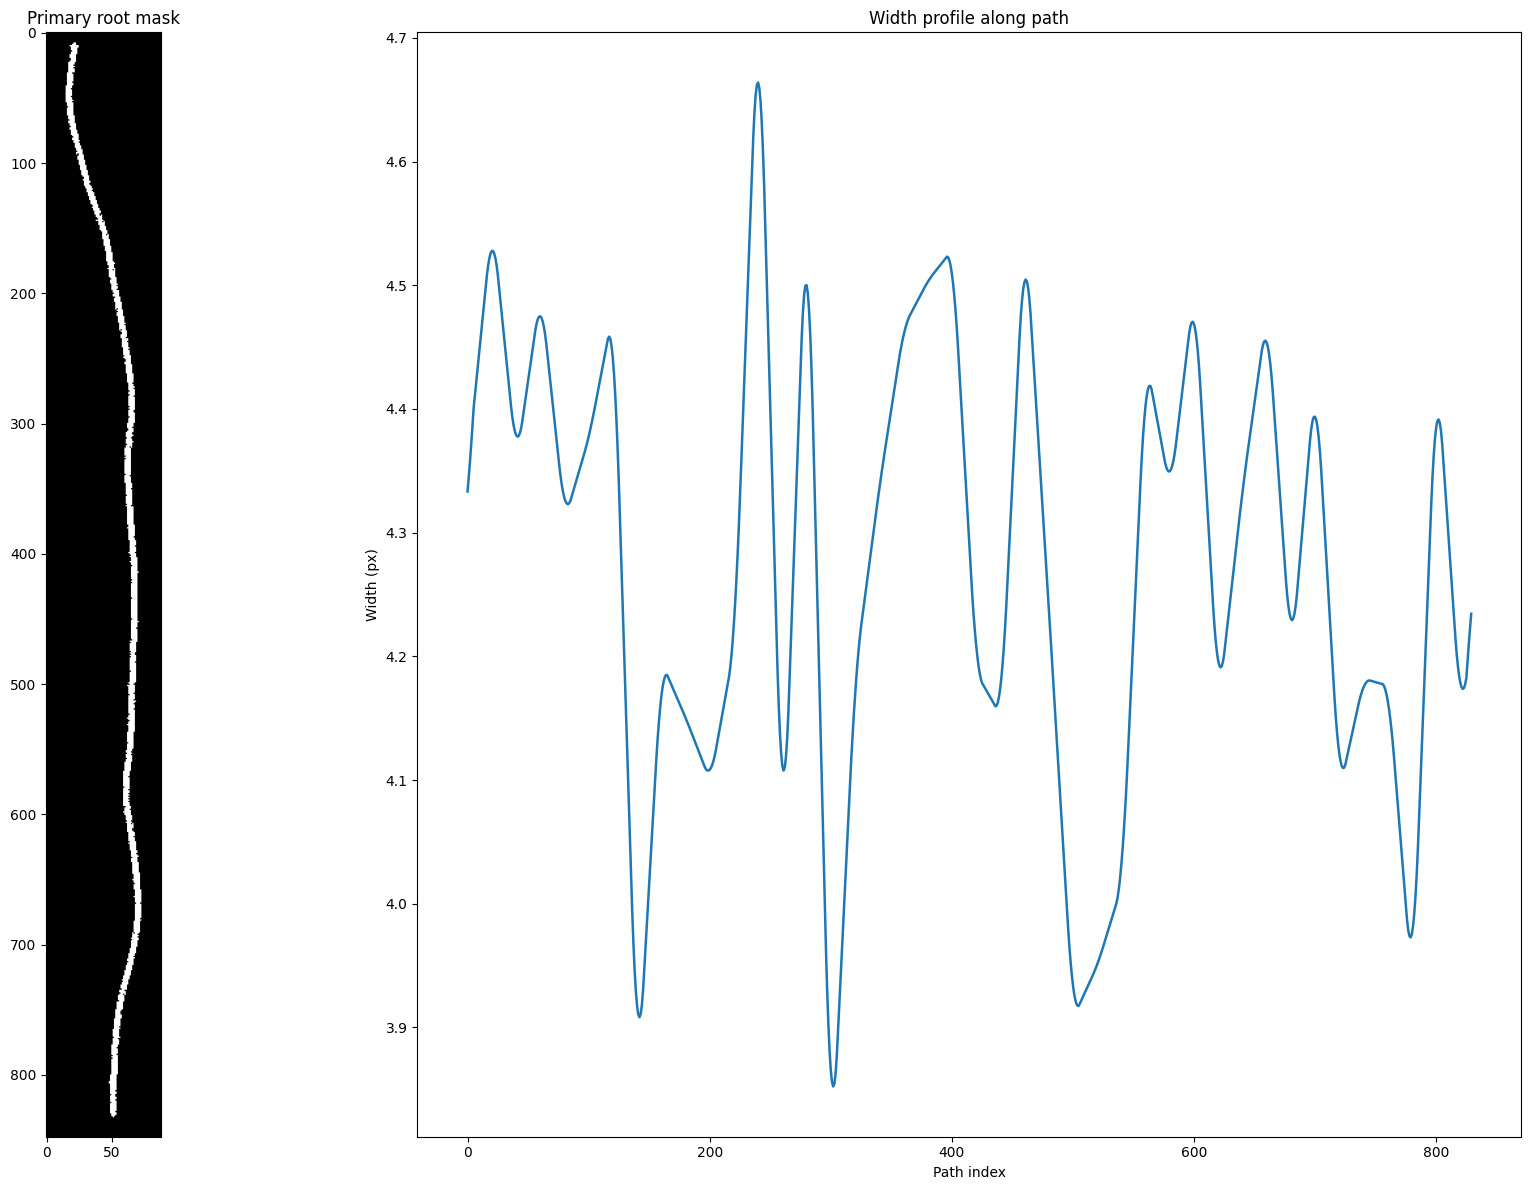

In [4]:
# Generate one medium-length root
config_name = "05_Medium_Smooth_Snake"
seed = 42

# root_id is an integer label embedded in the output metadata and filenames.
# It has no effect on generation — just identifies this root in a batch.
result = generate_single_primary_root(config_name, root_id=0, seed=seed)

print(f"Config:     {config_name}")
print(f"Seed:       {seed}")
print(f"Mask shape: {result['mask'].shape}")
print(f"Skeleton:   {result['metadata']['skeleton_length']} px")
print(f"Width info: taper={result['metadata']['width_info']['taper_bucket']}, "
      f"thin={result['metadata']['width_info']['is_thin']}")

# Display
fig, axes = plt.subplots(1, 2, figsize=(20, 12))
axes[0].imshow(result["mask"], cmap="gray")
axes[0].set_title("Primary root mask")
axes[1].plot(result["skeleton_widths"], linewidth=1.8)
axes[1].set_title("Width profile along path")
axes[1].set_xlabel("Path index")
axes[1].set_ylabel("Width (px)")
plt.tight_layout()
plt.show()

### 1.4 Generate different root styles

Let's compare a short kinky root, a long sweeping one, and an extra-long hybrid.

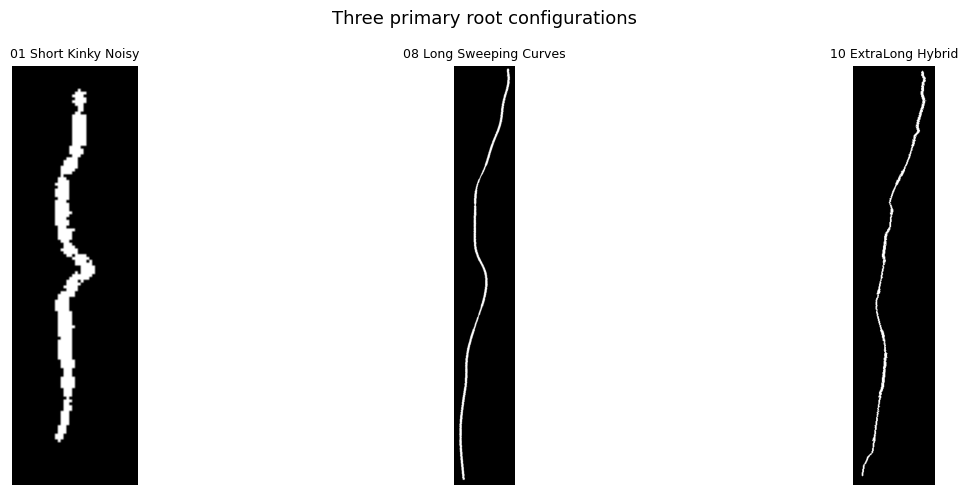

In [5]:
configs_to_show = [
    "01_Short_Kinky_Noisy",
    "08_Long_Sweeping_Curves",
    "10_ExtraLong_Hybrid",
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, cfg in zip(axes, configs_to_show):
    result = generate_single_primary_root(cfg, root_id=0, seed=123)
    ax.imshow(result["mask"], cmap="gray")
    ax.set_title(cfg.replace("_", " "), fontsize=9)
    ax.axis("off")
plt.suptitle("Three primary root configurations", fontsize=13)
plt.tight_layout()
plt.show()

### 1.5 Attach lateral roots

`generate_lateral_root_inline` takes a primary root result and attaches lateral branches directly, returning a composite mask and per-root label image.

Composite mask shape: (894, 529)

Total Lateral count: 9

  Lateral roots on or near the top of the tip: 2
  Other Lateral Roots:                         7


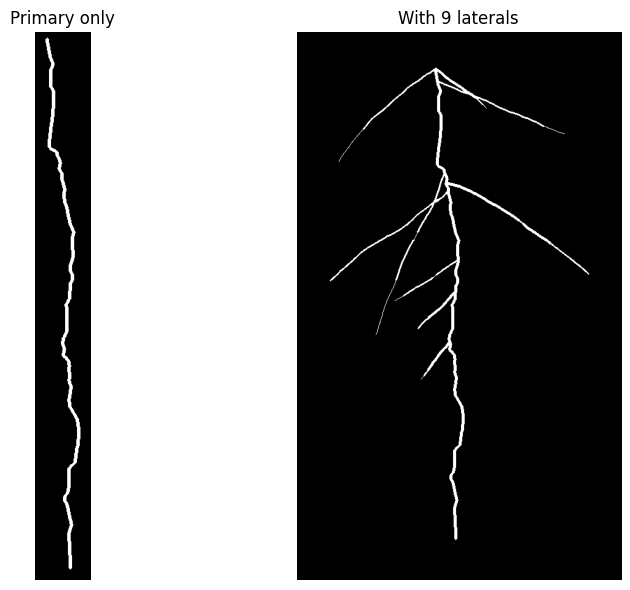

In [6]:
# Generate a primary root
primary = generate_single_primary_root("06_Medium_Clean_GroundTruth", root_id=0, seed=7)

# Attach laterals using "E_medium_small" mode
composite = generate_lateral_root_inline(
    primary_data=primary,
    config_name="08_Long_Sweeping_Curves                  ",
    lateral_mode_name="L_many_mixed",
    seed=8,
)

print(f"Composite mask shape: {composite['combined_mask'].shape}")
print(f"\nTotal Lateral count: {composite['metadata']['num_laterals']}\n")
print(f"  Lateral roots on or near the top of the tip: {composite['metadata']['num_top_tip_laterals']}")
print(f"  Other Lateral Roots:                         {composite['metadata']['num_normal_laterals']}")

# Display primary vs composite
fig, axes = plt.subplots(1, 2, figsize=(10, 6))
axes[0].imshow(primary["mask"], cmap="gray")
axes[0].set_title("Primary only")
axes[1].imshow(composite["combined_mask"], cmap="gray")
axes[1].set_title(f"With {composite['metadata']['num_laterals']} laterals")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### 1.6 Seed reproducibility

Same config + same seed = identical output. This is a hard requirement of the package.

In [7]:
r1 = generate_single_primary_root("04_Medium_Kinky_Noisy", root_id=0, seed=999)
r2 = generate_single_primary_root("04_Medium_Kinky_Noisy", root_id=0, seed=999)
print(f"Are the masks with the same seed identical?\n {np.array_equal(r1['mask'], r2['mask'])}")

Are the masks with the same seed identical?
 True


---
## 2. Batch Dataset Generation

The orchestrator generates roots across all (config × lateral mode) combinations. Here we generate just **2 roots per cell** for speed — a real dataset would use 100–600+.

In [8]:
from pyrootsim.dataset.orchestrator import (
    generate_rsa_dataset,
    build_generation_grid,
)

# Show the generation grid
grid = build_generation_grid()
print(f"Total grid cells: {len(grid)}")
print(f"(Each cell = 1 config × 1 lateral mode)")
print(f"With 2 roots per cell → {len(grid) * 2} individual roots")

Total grid cells: 123
(Each cell = 1 config × 1 lateral mode)
With 2 roots per cell → 246 individual roots


In [9]:
# Generate a tiny dataset (2 roots per cell)
OUTPUT_RSA = "tutorial_RSA_dataset"

summary = generate_rsa_dataset(
    output_dir=OUTPUT_RSA,
    num_per_cell=40,       # tiny for tutorial — use 100-600 for real datasets
    base_seed=42,
    num_workers=0,        # sequential for tutorial
)

pyrootsim — RSA DATASET GENERATION
Output:          tutorial_RSA_dataset
Primary configs: 12
Total cells:     123 (config × lateral_mode)
Roots per cell:  40
Total roots:     4920
Execution:       sequential
Base seed:       42
  01_Short_Kinky_Noisy: 5 lateral modes × 40 = 200 roots
  02_Short_Smooth_Clean: 5 lateral modes × 40 = 200 roots
  03_Short_Kinky_Smooth: 5 lateral modes × 40 = 200 roots
  04_Medium_Kinky_Noisy: 12 lateral modes × 40 = 480 roots
  05_Medium_Smooth_Snake: 12 lateral modes × 40 = 480 roots
  06_Medium_Clean_GroundTruth: 12 lateral modes × 40 = 480 roots
  07_Long_Kinky_Noisy: 12 lateral modes × 40 = 480 roots
  08_Long_Sweeping_Curves: 12 lateral modes × 40 = 480 roots
  09_Long_Smooth_Static: 12 lateral modes × 40 = 480 roots
  10_ExtraLong_Hybrid: 12 lateral modes × 40 = 480 roots
  11_ExtraLong_Curvy_Clean: 12 lateral modes × 40 = 480 roots
  12_ExtraLong_Mixed_Sweeping: 12 lateral modes × 40 = 480 roots



Generating roots: 100%|██████████| 4920/4920 [07:46<00:00, 10.54it/s]


GENERATION COMPLETE
Time:        466.9s (10.5 roots/sec)
Generated:   4920 / 4920
Failed:      0
Errors:      0
Top-tip lat: 3117 total across all roots
CC8 fallbk:  43
Pinches:     2039 roots w/ primary pinches, 5171 pri events, 24383 lat events
Thin roots:  1410 / 4920
Taper dist:  {'none': 2608, 'mild': 1228, 'strong': 1084, 'unknown': 0}

Config                                 OK  Fail  Err TpTip  Thin PriPn LatPn Modes
----------------------------------- ----- ----- ---- ----- ----- ----- ----- -----
01_Short_Kinky_Noisy                  200     0    0   148    70   310   230     5
02_Short_Smooth_Clean                 200     0    0   161    77   280   205     5
03_Short_Kinky_Smooth                 200     0    0   180    88   282   275     5
04_Medium_Kinky_Noisy                 480     0    0   340   177   631  2356    12
05_Medium_Smooth_Snake                480     0    0   381   172   666  2474    12
06_Medium_Clean_GroundTruth           480     0    0     0     0     0   

---
## 3. Petri Dish Composition

The composer assembles 5 individual root systems onto a shared canvas, simulating the layout of [NPEC's HADES high-throughput phenotyping system](https://www.npec.nl). Each dish gets a binary mask, a label image (unique ID per root), and optional overlap labels.

In [10]:
from pyrootsim.dish.composer import generate_all_dishes

OUTPUT_DISHES = "tutorial_petri_dishes"

dish_summary = generate_all_dishes(
    rsa_input_dir=OUTPUT_RSA,
    output_dir=OUTPUT_DISHES,
    num_dishes=900,
    base_seed=42,
    num_workers=0,
)

RIBEIROOT — PETRI DISH GENERATION
Input:       tutorial_RSA_dataset
Output:      tutorial_petri_dishes
Dishes:      900
Execution:   sequential
Min plants:  1
Indexed 4920 roots across 12 configs


Generating dishes: 100%|██████████| 900/900 [03:02<00:00,  4.94it/s]



GENERATION COMPLETE
Time:         182.7s (4.9 dishes/sec)
Generated:    900 / 900
Failed:       0
Avg plants:   4.61
Avg overlap:  24 px

Plants per dish distribution:
  2 plants:     5 (  0.6%) █
  3 plants:    43 (  4.8%) █
  4 plants:   250 ( 27.8%) ███████████
  5 plants:   602 ( 66.9%) ██████████████████████████

Summary: tutorial_petri_dishes/generation_summary.json
CSV Metadata: tutorial_petri_dishes/dish_metadata.csv


### 3.1 Visualise a composed dish

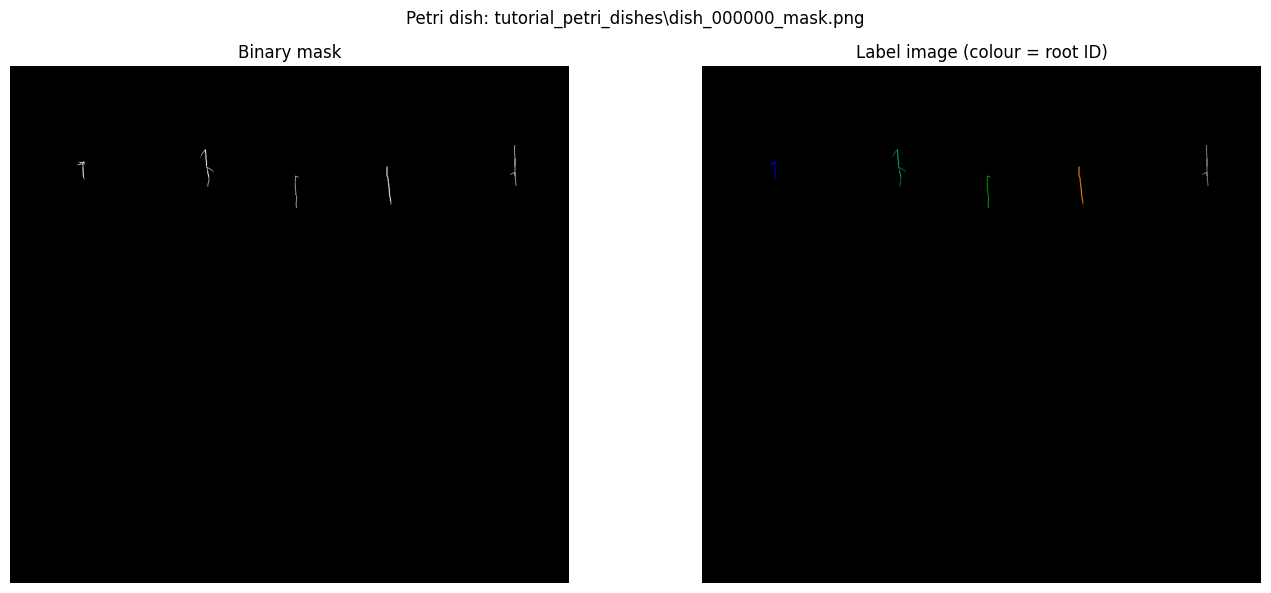

Canvas size: (2535, 2738)
Unique labels (incl. background): 14


In [11]:
import glob

# Load and display the first dish
mask_files = sorted(glob.glob(f"{OUTPUT_DISHES}/dish_*_mask.png"))
if mask_files:
    mask = np.array(Image.open(mask_files[0]))
    labels = np.array(Image.open(mask_files[0].replace("_mask.png", "_labels.png")))
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(mask, cmap="gray")
    axes[0].set_title("Binary mask")
    axes[1].imshow(labels, cmap="nipy_spectral")
    axes[1].set_title("Label image (colour = root ID)")
    for ax in axes:
        ax.axis("off")
    plt.suptitle(f"Petri dish: {mask_files[0].split('/')[-1]}", fontsize=12)
    plt.tight_layout()
    plt.show()
    
    print(f"Canvas size: {mask.shape}")
    print(f"Unique labels (incl. background): {len(np.unique(labels))}")
else:
    print("No dishes generated — check the RSA dataset output above.")

---
## 4. Dataset Splitting — Clean vs. Occluded

Before applying discontinuities, we split the dishes into two sets:
- **To-occlude**: dishes that will receive cuts (the majority)
- **Clean**: dishes kept pristine (used as clean test/val examples)

The split is stratified by dominant primary configuration so every root style appears in both sets.

In [12]:
from pyrootsim.dataset.splitter import split_clean_vs_occluded

OCCLUDED_DIR = "tutorial_dishes_to_occlude"
CLEAN_DIR = "tutorial_dishes_clean"

split_clean_vs_occluded(
    input_dir=OUTPUT_DISHES,
    occluded_dir=OCCLUDED_DIR,
    clean_dir=CLEAN_DIR,
    num_clean=100,           # keep 3 clean, rest get occluded
    seed=42,
)

Loading metadata and calculating split...

Copying 100 dishes to clean folder: tutorial_dishes_clean


Copying clean: 100%|██████████| 100/100 [00:00<00:00, 159.84it/s]



Copying 800 dishes to occluded folder: tutorial_dishes_to_occlude


Copying occluded: 100%|██████████| 800/800 [00:05<00:00, 151.45it/s]


STRATIFIED SPLIT REPORT
Configuration                       | Original | To Occlude | Clean 
----------------------------------------------------------------------
01_Short_Kinky_Noisy                | 67       | 59         | 8     
02_Short_Smooth_Clean               | 86       | 76         | 10    
03_Short_Kinky_Smooth               | 75       | 67         | 8     
04_Medium_Kinky_Noisy               | 64       | 57         | 7     
05_Medium_Smooth_Snake              | 64       | 57         | 7     
06_Medium_Clean_GroundTruth         | 84       | 75         | 9     
07_Long_Kinky_Noisy                 | 74       | 66         | 8     
08_Long_Sweeping_Curves             | 75       | 67         | 8     
09_Long_Smooth_Static               | 73       | 65         | 8     
10_ExtraLong_Hybrid                 | 78       | 69         | 9     
11_ExtraLong_Curvy_Clean            | 76       | 67         | 9     
12_ExtraLong_Mixed_Sweeping         | 84       | 75         | 9     
-------

---
## 5. Discontinuity Injection (Occlusion Pipeline)

The occlusion orchestrator applies three types of cuts to each dish:
- **2cc** — Simple cuts that split a root into 2 connected components
- **3cc** — Junction-targeting cuts producing 3 connected components
- **4cc** — X-crossing or bilateral junction cuts producing 4 connected components

Each cut is validated both locally and globally, phantom cuts are healed, and OBBs are written in YOLOv8 format.

In [13]:
from pyrootsim.discontinuity.orchestrator import run_occlusion_pipeline

OUTPUT_OCCLUDED = "tutorial_dishes_occluded"

occ_summary = run_occlusion_pipeline(
    petri_dish_dir=OCCLUDED_DIR,
    output_dir=OUTPUT_OCCLUDED,
    base_seed=42,
    num_workers=4,
)

pyrootsim — OCCLUSION PIPELINE
Input:       tutorial_dishes_to_occlude
Output:      tutorial_dishes_occluded
Dishes:      800
Execution:   4 workers
Edge margin: 18px


Occluding dishes: 100%|██████████| 800/800 [29:30<00:00,  2.21s/it]


pyrootsim — OCCLUSION PIPELINE COMPLETE
Time:           1771.0s (0.5 dishes/sec)
Dishes:         793 / 800
Failed:         7
Skipped (0 occ):0

CC Type    Targeted     Placed  Fill Rate
-------- ---------- ---------- ----------
2cc            3241       2544      78.5%
3cc            1084       1018      93.9%
4cc             418        264      63.2%
TOTAL          4743       3826

Avg occlusions/dish: 4.8

OBB Validation (post-hoc filter):
  Kept:             3826
  Dropped OBB:      49
  Dropped Fake 2cc: 692
  Pass rate:        98.74%

Density tier distribution:
      skip:     0 (  0.0%) █
   minimal:   101 ( 12.6%) ██████
     light:   164 ( 20.5%) ██████████
    medium:   241 ( 30.1%) ███████████████
     heavy:   206 ( 25.8%) ████████████
   extreme:    88 ( 11.0%) █████

Occlusions per dish histogram:
    0 occs:     1 █
    1 occs:    26 ███████
    2 occs:    78 █████████████████████
    3 occs:   135 █████████████████████████████████████
    4 occs:   128 █████████████████

### 5.1 Visualise an occluded dish

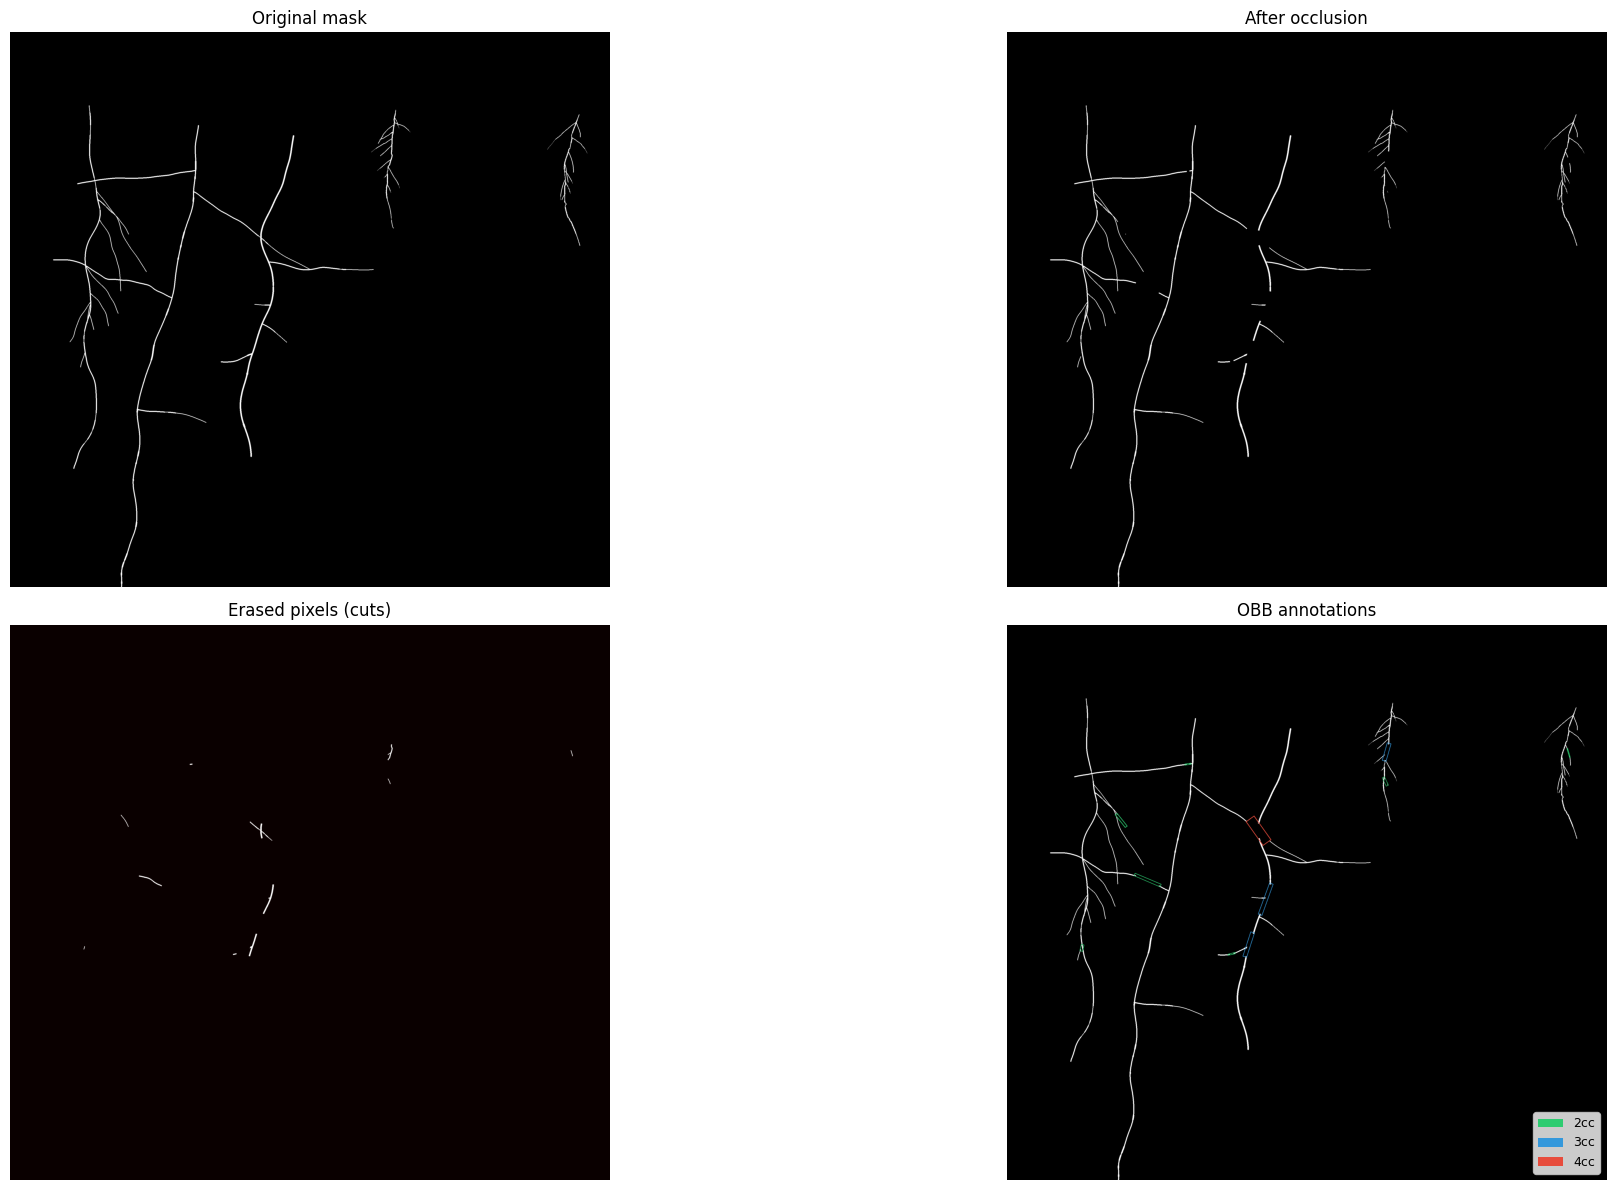

OBB annotations: 11 boxes (dish_000550_mask_occluded.png)
  0 0.937546 0.240631 0.933163 0.224458 0.934517 0.224030 0.938899 0.240203
  0 0.197151 0.366054 0.180314 0.343019 0.183346 0.340434 0.200183 0.363469
  0 0.368762 0.596007 0.368294 0.593837 0.380024 0.590881 0.380493 0.593050
  0 0.632062 0.291728 0.625459 0.276752 0.629089 0.274886 0.635691 0.289861
  0 0.125661 0.588862 0.121536 0.587748 0.124178 0.576331 0.128303 0.577445
  ... (6 more)


In [19]:
import os
import cv2

occ_masks = sorted(glob.glob(os.path.join(OUTPUT_OCCLUDED, "*_mask_occluded.png")))
orig_masks = [f for f in sorted(glob.glob(os.path.join(OUTPUT_OCCLUDED, "*_mask.png")))
              if "occluded" not in os.path.basename(f)]

# Pick a dish with more occlusions by checking OBB annotation count
best_idx, best_count = 0, 0
for i, occ_path in enumerate(occ_masks):
    obb_path = occ_path.replace("_mask_occluded.png", "_obb_all.txt")
    if os.path.exists(obb_path):
        with open(obb_path) as f:
            count = len(f.readlines())
        if count > best_count:
            best_count = count
            best_idx = i

if occ_masks and orig_masks:
    original = np.array(Image.open(orig_masks[best_idx]))
    occluded = np.array(Image.open(occ_masks[best_idx]))
    h, w = occluded.shape

    # Difference highlights the cuts
    diff = original.astype(int) - occluded.astype(int)
    diff = np.clip(diff, 0, 255).astype(np.uint8)

    # Build OBB overlay on the occluded mask
    obb_colors = {
        "0": ((46, 204, 113), "2cc"),
        "1": ((52, 152, 219), "3cc"),
        "2": ((231, 76, 60),  "4cc"),
    }
    obb_vis = cv2.cvtColor(occluded, cv2.COLOR_GRAY2RGB)

    obb_file = occ_masks[best_idx].replace("_mask_occluded.png", "_obb_all.txt")
    obb_lines = []
    if os.path.exists(obb_file):
        with open(obb_file) as f:
            obb_lines = f.readlines()

        for line in obb_lines:
            parts = line.strip().split()
            class_id = parts[0]
            coords = [float(x) for x in parts[1:]]
            pts = np.array([
                [coords[i] * w, coords[i + 1] * h]
                for i in range(0, len(coords), 2)
            ], dtype=np.int32)
            color = obb_colors.get(class_id, ((255, 255, 255), "unknown"))[0]
            cv2.polylines(obb_vis, [pts], isClosed=True, color=color, thickness=2)

    fig, axes = plt.subplots(2, 2, figsize=(24, 12))
    axes[0, 0].imshow(original, cmap="gray")
    axes[0, 0].set_title("Original mask")
    axes[0, 1].imshow(occluded, cmap="gray")
    axes[0, 1].set_title("After occlusion")
    axes[1, 0].imshow(diff, cmap="hot")
    axes[1, 0].set_title("Erased pixels (cuts)")
    axes[1, 1].imshow(obb_vis)
    axes[1, 1].set_title("OBB annotations")
    for ax in axes.flat:
        ax.axis("off")

    # Legend
    from matplotlib.patches import Patch
    legend_handles = [Patch(facecolor=np.array(c) / 255, label=name)
                      for _, (c, name) in obb_colors.items()]
    axes[1, 1].legend(handles=legend_handles, loc="lower right", fontsize=9)

    plt.tight_layout()
    plt.show()

    print(f"OBB annotations: {len(obb_lines)} boxes ({os.path.basename(occ_masks[best_idx])})")
    for line in obb_lines[:5]:
        print(f"  {line.strip()}")
    if len(obb_lines) > 5:
        print(f"  ... ({len(obb_lines) - 5} more)")
else:
    print("No occluded dishes found — the to-occlude set may have been too small.")

### 5.2 Visualise root labels and overlap

C:\Users\stude\AppData\Local\Temp\ipykernel_5636\425360944.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  lateral_cmap = plt.cm.get_cmap("tab20")
C:\Users\stude\AppData\Local\Temp\ipykernel_5636\425360944.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


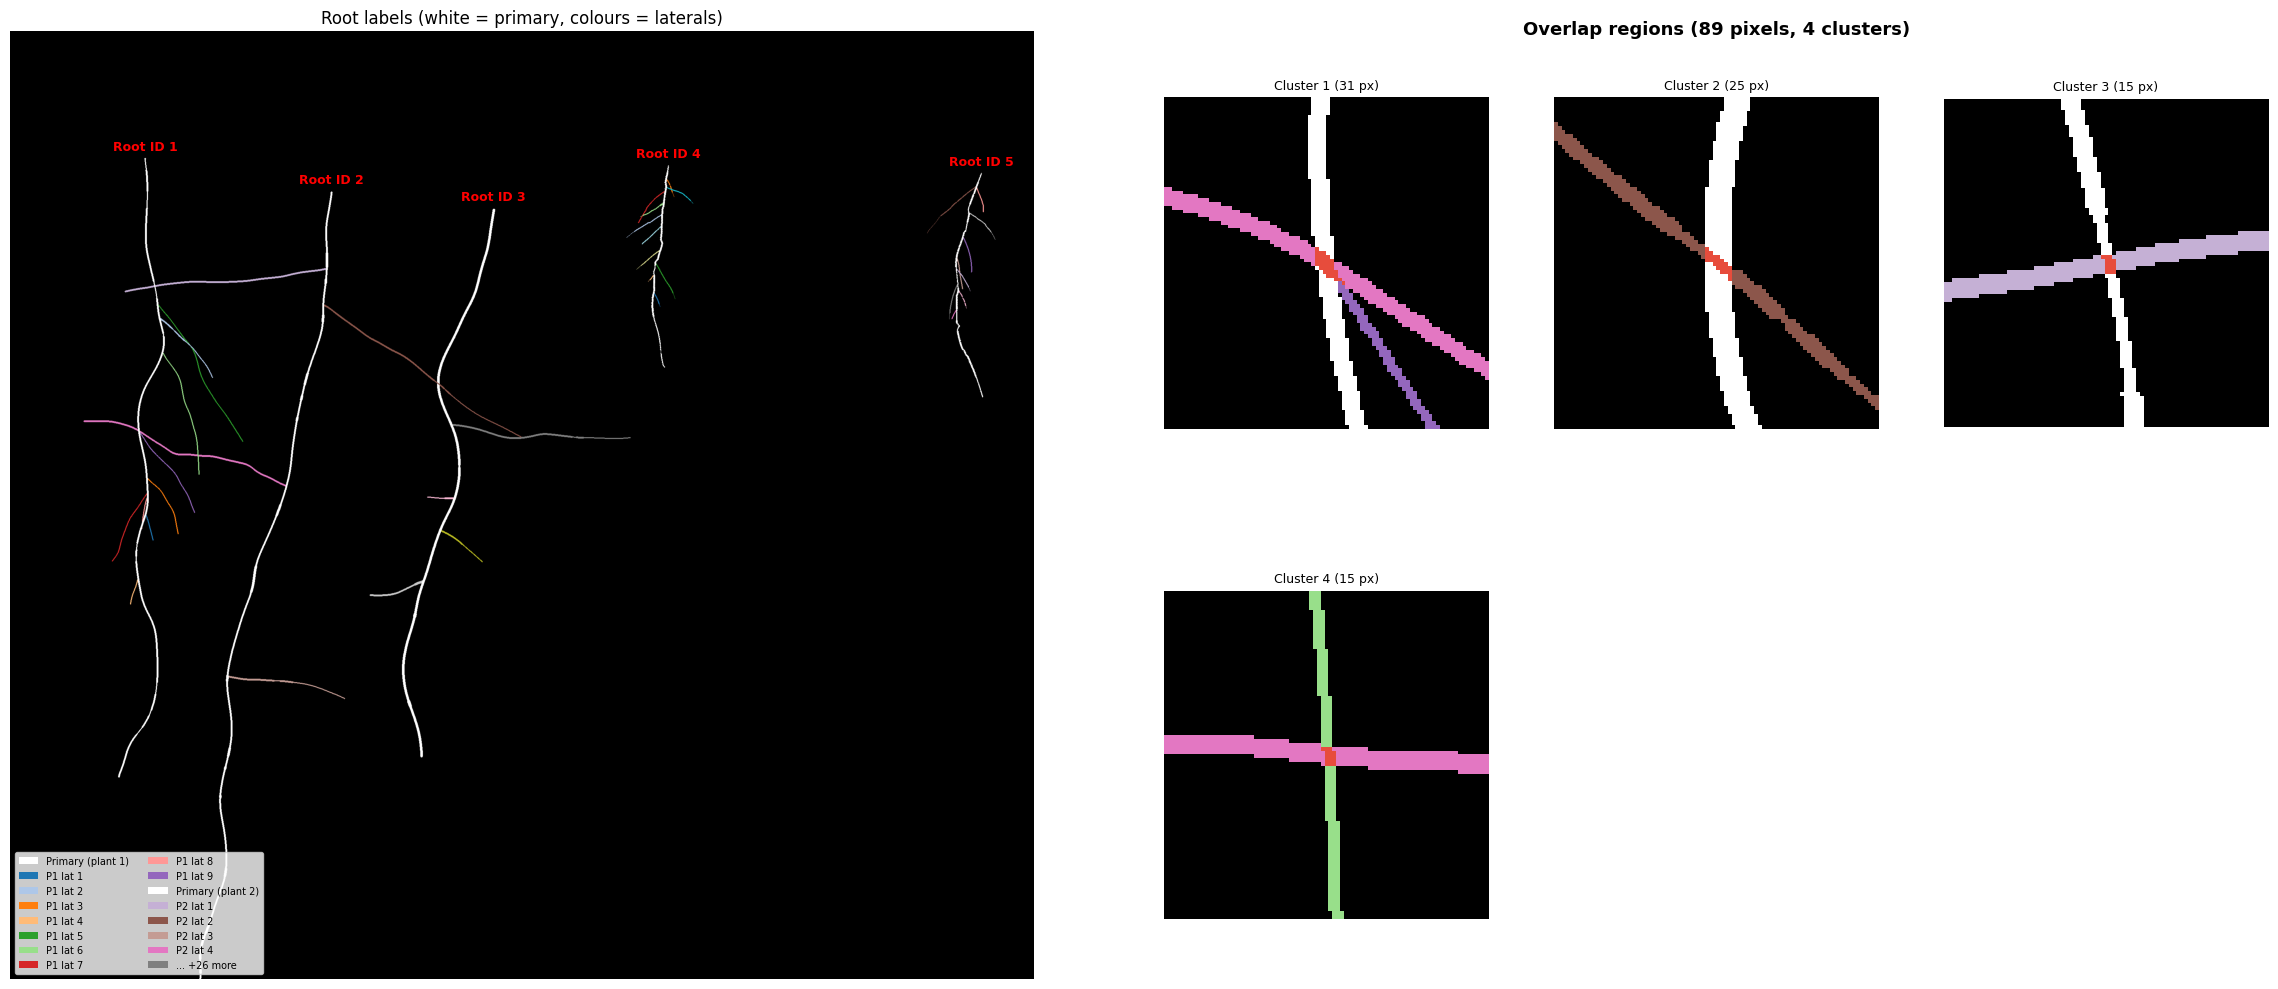

Dish: dish_000550_mask_occluded.png
Unique roots: 41 (5 primaries, 36 laterals)
Overlap pixels: 89


In [18]:
# Use the same dish from 5.1
dish_base = occ_masks[best_idx].replace("_mask_occluded.png", "")
labels_path = dish_base + "_labels.png"
overlap_path = dish_base + "_overlap.png"

if os.path.exists(labels_path):
    labels = np.array(Image.open(labels_path))
    h, w = labels.shape

    # Decode label structure: plant_id = val // 100, lateral_id = val % 100
    unique_labels = np.unique(labels)
    unique_labels = unique_labels[unique_labels > 0]

    lateral_cmap = plt.cm.get_cmap("tab20")
    lat_color_idx = 0

    label_vis = np.zeros((h, w, 3), dtype=np.uint8)
    legend_entries = []
    primary_centers = {}  # plant_id -> (center_y, center_x)

    for lbl in sorted(unique_labels):
        plant_id = int(lbl) // 100
        lateral_id = int(lbl) % 100
        mask = labels == lbl

        if lateral_id == 0:
            # Primary root — white
            label_vis[mask] = [255, 255, 255]
            legend_entries.append((f"Primary (plant {plant_id})", [1.0, 1.0, 1.0]))
            # Find top of primary for label placement
            ys = np.where(mask)[0]
            xs = np.where(mask)[1]
            top_idx = np.argmin(ys)
            primary_centers[plant_id] = (ys[top_idx], xs[top_idx])
        else:
            color = lateral_cmap(lat_color_idx % 20)[:3]
            label_vis[mask] = [int(c * 255) for c in color]
            legend_entries.append((f"P{plant_id} lat {lateral_id}", list(color)))
            lat_color_idx += 1

    # --- Column 1: Label image with root ID text ---
    has_overlap = os.path.exists(overlap_path)
    overlap = np.array(Image.open(overlap_path)) if has_overlap else None

    ncols = 2 if has_overlap and np.any(overlap > 0) else 1
    fig, axes = plt.subplots(1, ncols, figsize=(12 * ncols, 10))
    if ncols == 1:
        axes = [axes]

    axes[0].imshow(label_vis)
    axes[0].set_title("Root labels (white = primary, colours = laterals)")
    axes[0].axis("off")

    # Place red "Root ID X" text above each primary
    for plant_id, (cy, cx) in primary_centers.items():
        axes[0].text(cx, cy - 15, f"Root ID {plant_id}",
                     fontsize=9, fontweight="bold", color="red",
                     ha="center", va="bottom",
                     bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.7))

    # Legend
    from matplotlib.patches import Patch
    max_legend = 15
    handles = [Patch(facecolor=c, label=name) for name, c in legend_entries[:max_legend]]
    if len(legend_entries) > max_legend:
        handles.append(Patch(facecolor="gray", label=f"... +{len(legend_entries) - max_legend} more"))
    axes[0].legend(handles=handles, loc="lower left", fontsize=7, ncol=2)

    # --- Column 2: Zoomed overlap patches ---
    if ncols == 2:
        overlap_mask = overlap > 0
        n_overlap = np.count_nonzero(overlap_mask)

        # Find connected overlap clusters and zoom into each
        from scipy import ndimage as ndi
        labeled_overlap, n_clusters = ndi.label(overlap_mask)

        # Get bounding boxes for each cluster
        cluster_bboxes = []
        for cl in range(1, n_clusters + 1):
            ys, xs = np.where(labeled_overlap == cl)
            if len(ys) < 3:
                continue
            pad = 40
            y1, y2 = max(0, ys.min() - pad), min(h, ys.max() + pad)
            x1, x2 = max(0, xs.min() - pad), min(w, xs.max() + pad)
            cluster_bboxes.append((y1, y2, x1, x2, len(ys)))

        # Sort by size descending, show up to 6
        cluster_bboxes.sort(key=lambda b: b[4], reverse=True)
        show_clusters = cluster_bboxes[:6]
        n_patches = len(show_clusters)

        if n_patches == 0:
            axes[1].text(0.5, 0.5, "No overlap regions found",
                         transform=axes[1].transAxes, ha="center", fontsize=14)
            axes[1].axis("off")
        else:
            # Remove the placeholder axis and create a grid of subplots
            axes[1].remove()
            rows = (n_patches + 2) // 3
            cols = min(n_patches, 3)
            gs = fig.add_gridspec(rows, cols, left=0.52, right=0.98,
                                  top=0.92, bottom=0.05, hspace=0.3, wspace=0.2)

            fig.text(0.75, 0.96, f"Overlap regions ({n_overlap} pixels, {n_patches} clusters)",
                     ha="center", fontsize=13, fontweight="bold")

            for idx, (y1, y2, x1, x2, size) in enumerate(show_clusters):
                r, c = idx // cols, idx % cols
                ax = fig.add_subplot(gs[r, c])

                # Show labels with overlap highlighted in red
                patch = label_vis[y1:y2, x1:x2].copy()
                overlap_patch = overlap_mask[y1:y2, x1:x2]
                patch[overlap_patch] = [231, 76, 60]

                ax.imshow(patch)
                ax.set_title(f"Cluster {idx + 1} ({size} px)", fontsize=9)
                ax.axis("off")

    plt.tight_layout()
    plt.show()

    print(f"Dish: {os.path.basename(occ_masks[best_idx])}")
    print(f"Unique roots: {len(unique_labels)} "
          f"({sum(1 for l in unique_labels if l % 100 == 0)} primaries, "
          f"{sum(1 for l in unique_labels if l % 100 != 0)} laterals)")
    if has_overlap:
        print(f"Overlap pixels: {np.count_nonzero(overlap > 0)}")
else:
    print("Labels file not found for this dish.")

---
## 6. Final Train / Val / Test Split

The last step combines the occluded and clean dishes and splits them into train (70%), val (20%), and test (10%) sets, stratified by primary configuration and occlusion status.


In [15]:
from pyrootsim.dataset.splitter import split_train_val_test
import json

FINAL_DATASET = "tutorial_final_dataset"

split_train_val_test(
    clean_csv_path=os.path.join(CLEAN_DIR, "clean_split_metadata.csv"),
    occluded_csv_path=os.path.join(OCCLUDED_DIR, "occluded_split_metadata.csv"),
    clean_img_dir=CLEAN_DIR,
    occluded_img_dir=OUTPUT_OCCLUDED,
    output_base_dir=FINAL_DATASET,
    seed=42,
)

Loading metadata...
Total dishes found: 900

Copying files into dataset structure...

Processing TRAIN set (630 dishes)...


Copying train: 100%|██████████| 630/630 [00:02<00:00, 259.92it/s]



Processing VAL set (180 dishes)...


Copying val: 100%|██████████| 180/180 [00:00<00:00, 324.13it/s]



Processing TEST set (90 dishes)...


Copying test: 100%|██████████| 90/90 [00:00<00:00, 454.80it/s]


                         FINAL DATASET STRATIFICATION REPORT                         

1. HIGH-LEVEL SPLIT (Target: 70% Train / 20% Val / 10% Test)
--------------------------------------------------
TRAIN   |   630 dishes (70.0%) | Occluded:  559 | Clean:   71
VAL     |   180 dishes (20.0%) | Occluded:  158 | Clean:   22
TEST    |    90 dishes (10.0%) | Occluded:   83 | Clean:    7

2. CONFIGURATION DISTRIBUTION ACROSS SPLITS
-------------------------------------------------------------------------------------
Config Name                    | Train (O/C) | Val (O/C)   | Test (O/C)  | Total
-------------------------------------------------------------------------------------
01_Short_Kinky_Noisy           |   41/6    |   12/2    |    6/0    |    67
02_Short_Smooth_Clean          |   53/7    |   15/2    |    8/1    |    86
03_Short_Kinky_Smooth          |   47/6    |   13/2    |    7/0    |    75
04_Medium_Kinky_Noisy          |   40/5    |   11/2    |    6/0    |    64
05_Medium_Smooth

---
## 7. Cleanup

Uncomment and run the cell below to remove all tutorial outputs.

In [ ]:
# import shutil
# import os
# for d in [OUTPUT_RSA, OUTPUT_DISHES, OCCLUDED_DIR, CLEAN_DIR,
#           OUTPUT_OCCLUDED, FINAL_DATASET]:
#     if os.path.exists(d):
#         shutil.rmtree(d)
#         print(f"Removed {d}")

---
## 8. Future Work

PyRootSim is under active development. Planned improvements include:

- **Species profile system** — A dataclass-based configuration layer so users can define custom species profiles (thickness ranges, branching patterns, segmentation artefact levels) without editing internal config dictionaries. The current defaults approximate *Arabidopsis thaliana* and have not been validated by a plant scientist.

- **Dish composition controls** — Expose canvas size, number of seedlings per dish, placement strategy, and box layout as user-facing parameters instead of hard-coded values tied to the NPEC HADES system.

- **New discontinuity types** — Extend the cut library beyond 2cc/3cc/4cc to simulate additional real-world segmentation challenges (e.g. uncontrolled occlusions that remove X components).

- **Evaluation & morphological metrics** — Utilities to compare synthetic vs. real root images quantitatively (skeleton length distributions, branching angle histograms, width profiles) to help users validate that their custom species profiles approximate reality.

- **ML dataset integration** — Dataset loaders for PyTorch and TensorFlow, and export to standard formats (COCO, YOLO) beyond the current YOLOv8 OBB output.

- **Plant science validation** — Collaboration with plant scientists to calibrate generation parameters against real phenotyping data from *Arabidopsis thaliana* and possibly extend support to other species (e.g. rice, maize).

- **Documentation** — Full API reference (Sphinx), additional tutorials, and contributed example notebooks.

If you are interested in this package and would like to help me contribute to it please email me at francisco.ribeiro.mansilha@gmail.com or connect with me on Linkedin!